In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [7]:
data = pd.read_csv('Body_weight.csv')

In [9]:
data.head()


,Weight,Height,Age,Gender
0,79,1.80,35,Male
1,69,1.68,39,Male
2,73,1.82,25,Male
3,95,1.70,60,Male
4,82,1.87,27,Male


In [11]:
data.shape

(10, 4)

In [13]:
data.isnull().sum()

Weight    0
Height    0
Age       0
Gender    0
dtype: int64

In [15]:
data['Gender'] = data['Gender'].map({'Male':1,'Female':0})

In [17]:
x = data.iloc[:,1:4].values
y = data.iloc[:,0:1].values

In [19]:
x_train, x_test, y_train, y_test = train_test_split(x,y,
        test_size=0.2, random_state = 42)

In [21]:
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [23]:
print(y_pred)
print(y_test)

[[56.85651025]
 [79.10576115]]
[[64]
 [69]]


In [29]:
print(model.intercept_)

[-3.05521724]


In [31]:
print(model.coef_)

[[32.8353363   0.31729474 14.62311848]]


In [35]:
from sklearn.metrics import r2_score, mean_squared_error

In [37]:
print("R2 Score :", r2_score(y_test, y_pred))

R2 Score : -11.252468343750815


In [39]:
print("Mean Squared Error :", mean_squared_error(y_test, y_pred))

Mean Squared Error : 76.5779271484426


In [41]:
new_person = [[1.75,30,1]]
prediction = model.predict(new_person)
print("Predicted Weight =", prediction)

Predicted Weight = [[78.54858202]]


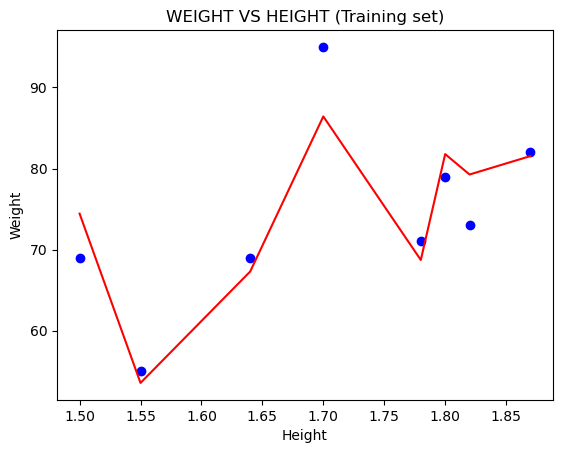

In [43]:
import numpy as np

idx = np.argsort(x_train[:,0])

plt.scatter(x_train[:,0], y_train, color='blue')
plt.plot(x_train[idx,0], model.predict(x_train)[idx], color='red')

plt.title('WEIGHT VS HEIGHT (Training set)')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.show()

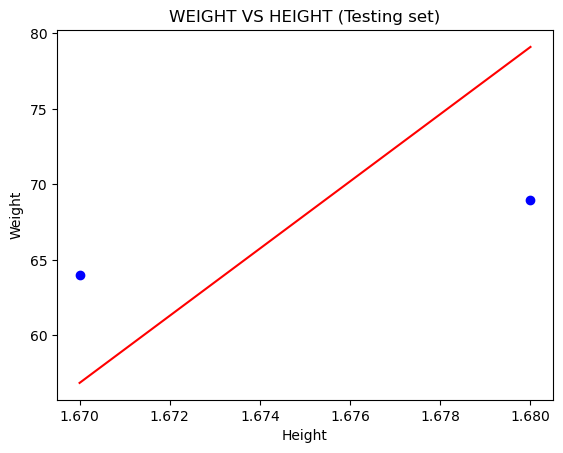

In [45]:
idx = np.argsort(x_test[:,0])

plt.scatter(x_test[:,0], y_test, color='blue')
plt.plot(x_test[idx,0], model.predict(x_test)[idx], color='red')

plt.title('WEIGHT VS HEIGHT (Testing set)')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.show()